# Optimising for What? Generative Engine Optimisation Beyond the Generation Stage
#### RQ: How do content-based GEO edits affect the retrieval and generation stages of Generative Search Engines?
#### H1: Content-based GEO edits significantly alter a document's retrieval rank within the retrieval stage of a GSE.

---
**Authors:** Leonard Rampf, Niklas Keckeisen

**Advisors:** Michail Batikas

**Submission Date:** 21.05.2026

# Table of Contents
- [Introduction](#Introduction)
- [Data Preparation](#Data-Preparation)
  - [Import Statements](#Import-Statements)
  - [Data Loading](#Data-Loading)
  - [Data Investigation](#Data-Investigation)
  - [Data Preprocessing](#Data-Preprocessing)
- [Descriptive Analysis](#Descriptive-Analysis)
- [Hypothesis Testing](#Hypothesis-Testing)
  - [Wilcoxon](#Wilcoxon)
    - [Assumptions](#Assumptions)
    - [Testing](#Testing)
      - [Sensitivity Analysis](#Sensitivity-Analysis)
  - [Sign Test](#Sign-Test)
    - [Assumptions](#Assumptions)
    - [Testing](#Testing-1)

# Introduction

This notebook evaluates H1: Content-based GEO edits significantly alter a document's retrieval rank within the retrieval stage of a GSE.
<br>
<br>

**Design**

A within-subjects, paired comparison of each target document's retrieval rank under its unedited baseline vs. each of its 21 GEO-edited counterparts (10 single edits + 11 combined edits). The retrieval environment — query, competitor pool, retrieval engine, serving parameters — is held constant across the two states, so any observed rank shift is attributable to the manipulation. The unit of analysis is the paired rank (r_baseline, r_edited) on a 1-to-10 scale; the dependent variable is the within-pair shift Δ = r_baseline − r_edited.
<br>
<br>

**Sample**

After cluster-wise exclusion of base queries with unstable competitor pools (<9 competitors returned in any of the 22 runs), the analysis sample is N = 411 paired observations per GEO condition (8,631 total), exceeding the a priori power threshold of 368.
<br>
<br>

**Analytical Approach**
- Descriptive statistics across baseline, edited, and delta: median ranks, IQRs, MRR, Top-3 presence, and proportional mobility (% Improved / Unchanged / Worsened); 11×11 transition-matrix heatmaps per condition.
- Inferential testing — Wilcoxon signed-rank test with Pratt's modification (primary) and the Sign Test (robustness check on symmetry).
- Multiple-comparison control — Holm-Bonferroni step-down across the 21 conditions.
- Magnitude — standardized Wilcoxon effect size r, with bootstrap 95% CIs.


# Data Preparation

## Import Statements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
import os
import json
from scipy.stats import wilcoxon, norm, kruskal, skew, binomtest, rankdata
from statsmodels.stats.multitest import multipletests

## Data Loading

First, the csv file containing the results of the retrieval stage is loaded. 

In [2]:
# define path and load data
relative_path = os.path.join("..", "..", "data", "retail", "retrieval", "20260413_retrieval_results_geo_v2.csv")
input_file = os.path.abspath(relative_path)

df = pd.read_csv(input_file)

## Data Investigation

After loading the data, the dataframe is investigated with standard measures. 

In [3]:
# investigate df
df.head()

,query_id,query,doc_id,method,doc_text,rank,is_target
0,50881_doc,holidaytraditions,50881_doc_comp_2,default_method,Name: HolidayTraditions State Trooper Personal...,1,0
1,50881_doc,holidaytraditions,50881_doc_comp_3,default_method,Name: Personalized Christmas Ornaments Family ...,2,0
2,50881_doc,holidaytraditions,50881_doc_comp_9,default_method,Name: Personalized Christmas Ornaments Family ...,3,0
3,50881_doc,holidaytraditions,50881_doc_TARGET,default_method,Name: Personalized Christmas Ornaments 2020 – ...,4,1
4,50881_doc,holidaytraditions,50881_doc_comp_1,default_method,Name: Kids Christmas Ornaments 2021 – Personal...,5,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109875 entries, 0 to 109874
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   query_id   109875 non-null  object
 1   query      109875 non-null  object
 2   doc_id     109875 non-null  object
 3   method     109875 non-null  object
 4   doc_text   109875 non-null  object
 5   rank       109875 non-null  int64 
 6   is_target  109875 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 5.9+ MB


In [5]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [6]:
print(f"Number of unique values in 'query_id': {df['query_id'].nunique()}")
print(f"Number of unique values in 'query': {df['query'].nunique()}")
print(f"Number of unique values in 'doc_id': {df['doc_id'].nunique()}")
print(f"Number of unique values in 'method': {df['method'].nunique()}")
print(f"Number of unique values in 'doc_text': {df['doc_text'].nunique()}")
print(f"Number of unique values in 'rank': {df['rank'].nunique()}")
print(f"Number of unique values in 'is_target': {df['is_target'].nunique()}")

Number of unique values in 'query_id': 11000
Number of unique values in 'query': 500
Number of unique values in 'doc_id': 109875
Number of unique values in 'method': 1
Number of unique values in 'doc_text': 15089
Number of unique values in 'rank': 10
Number of unique values in 'is_target': 2


No unusual results. Output is as expected. 

## Data Preprocessing

After loading, the preveailing errors of the retrieval stage are investigated. First the 15 errors with missing target documents are identified and injected using the raw jsonl originally uploaded to Vertex AI search. These ghost targets are marked and penalized with a rank of k + 1, where k is the max number of documents in a query_id. 

In [7]:
# 1. FILE CONFIGURATION
jsonl_relative_path = os.path.join("..", "..", "data", "retail", "retrieval", "20260413_vertex_geoedits_v1.jsonl") 
jsonl_baseline_path = os.path.abspath(jsonl_relative_path)

def inject_ghost_targets_with_jsonl(df):
    print("Scanning for Missing Targets...")
    
    # 1. Find the missing queries
    all_queries = df['query_id'].unique()
    queries_with_targets = df[df['is_target'] == 1]['query_id'].unique()
    missing_target_queries = set(all_queries) - set(queries_with_targets)
    
    print(f"Found {len(missing_target_queries)} queries missing their Target document.")
    
    if len(missing_target_queries) > 0:
        # 2. Extract the true query text, doc_id, and doc_text from the JSONL
        print("Mapping original text and target details from JSONL baseline...")
        target_map = {}
        
        with open(jsonl_baseline_path, 'r', encoding='utf-8') as file:
            for line in file:
                record = json.loads(line.strip())
                
                doc_id = record.get("id", "")
                struct_data = record.get("structData", {})
                q_id = struct_data.get("query_id")
                
                if q_id in missing_target_queries:
                    if "TARGET" in doc_id.upper():
                        target_map[q_id] = {
                            "query": struct_data.get("original_query", "UNMAPPED"),
                            "doc_id": doc_id,
                            "text": struct_data.get("text", "N/A") 
                        }

        # 3. Create the penalized rows with true context
        ghost_rows = []
        for q_id in missing_target_queries:
            # Retrieve the mapped data, with a safety fallback
            mapped_data = target_map.get(q_id, {
                "query": "UNMAPPED", 
                "doc_id": "GHOST_TARGET_NOT_FOUND_IN_JSONL", 
                "text": "TEXT_NOT_FOUND"
            }) 
            
            ghost_rows.append({
                "query_id": q_id,
                "query": mapped_data["query"],
                "doc_id": mapped_data["doc_id"],       
                "method": "imputed_penalty",
                "doc_text": mapped_data["text"],       
                "rank": 11,                            # THE PENALTY
                "is_target": 1
            })
            
        ghost_df = pd.DataFrame(ghost_rows)
        
        # 4. Inject and Return
        df_final = pd.concat([df, ghost_df], ignore_index=True)
        print("Injection complete.")
        return df_final
        
    else:
        print("No missing targets found. The dataset is already perfectly intact.")
        return df
        
df2 = inject_ghost_targets_with_jsonl(df)

Scanning for Missing Targets...
Found 15 queries missing their Target document.
Mapping original text and target details from JSONL baseline...
Injection complete.


The dataframe is displayed to analyse if the injection worked properly.

In [8]:
# Filter the dataframe for the exact flag we used for the Ghost Targets
ghost_cases = df2[df2['method'] == 'imputed_penalty']

# 1. Verify the count
print(f"Total Ghost Cases Confirmed in Dataframe: {len(ghost_cases)}")

# 2. Visually inspect the critical columns
display_cols = ['query_id', 'query', 'doc_id', 'rank', 'doc_text']

# Using .head(15) just to cleanly print all of them
display(ghost_cases[display_cols].head(15))

Total Ghost Cases Confirmed in Dataframe: 15


,query_id,query,doc_id,rank,doc_text
109875,28384_FQS(doc),computer repair tool kit,28384_FQS_doc__TARGET,11,**Name:** Kaisi 126 in 1 Precision Screwdriver...
109876,54484_LLMstxt(doc),iphone plus 8 charger case,54484_LLMstxt_doc__TARGET,11,```markdown\n# VICSEED Super Strong Magnet Pow...
109877,8070_Fluency(doc),all clad measuring cups and spoons,8070_Fluency_doc__TARGET,11,Name: Measuring Spoons: U-Taste 18/8 Stainless...
109878,28024_FCQS(doc),combed cotton sheet,28024_FCQS_doc__TARGET,11,**Name:** 300 Thread Count Jacquard Polka Dot ...
109879,112260_FS(doc),wireless wifi security camera system,112260_FS_doc__TARGET,11,**Name:** 1080P Wireless Security Camera Syste...
109880,28024_Quotes(doc),combed cotton sheet,28024_Quotes_doc__TARGET,11,Name: 300 Thread Count Jacquard Polka Dot Dark...
109881,115821_Statistics(doc),zokea night light,115821_Statistics_doc__TARGET,11,Name: SomeShine Kids Night Light - Rechargeabl...
109882,49199_UniqueWords(doc),hard wax warmer,49199_UniqueWords_doc__TARGET,11,Name: Tress Wellness Waxing Kit Wax Warmer for...
109883,54484_FCQS(doc),iphone plus 8 charger case,54484_FCQS_doc__TARGET,11,**Product Name:** VICSEED Car Phone Mount - Ma...
109884,94458_Fluency(doc),sliming waist trainer,94458_Fluency_doc__TARGET,11,Name: Best Neoprene Waist Trainer Corset Sweat...


**Sample Filter:**
The analysis is restricted to N = 411 base queries by applying cluster-wise exclusion: if any one of the 22 condition runs (baseline + 21 GEO edits) for a given query returns fewer than 9 competitor documents, all 22 paired observations for that query are dropped, not just the unstable run. This is deliberately conservative. The within-subjects design assumes the competitive document pool is static across baseline and edited states; admitting a query where even a single condition saw a degraded pool would introduce an environmental confound independent of the GEO treatment, and would also break the balanced structure that lets us compare the 21 conditions against an identical baseline distribution.

Note: This is deliberately done after ghost target injection. Of the 15 imputed ghost targets, 11 survive the strict filter and enter the analysis at rank 11; this asymmetric treatment, imputing missing targets as a genuine worst-case outcome but excluding base_ids with missing competitors, preserves the dependent variable's signal while maintaining the static-pool assumption that the within-subjects design requires.

The filter is conducted below. 

In [9]:
# PART 1: TARGET IDENTIFICATION
# Remove the column limit and widen display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Strictly isolate the target documents
targets = df2[df2['is_target'] == 1].copy()

# The order here is mathematically critical to prevent overlapping abbreviations. Assumes the naming convention is airtight. 
dimension_hierarchy = [
    ('ContentImprovement', 'Content Improvement'),
    ('SimpleLanguage', 'Simple Language'),
    ('TechnicalTerms', 'Technical Terms'),
    ('UniqueWords', 'Unique Words'),
    ('Authoritative', 'Authoritative'),
    ('Statistics', 'Statistics'),
    ('Citations', 'Citations'),
    ('Fluency', 'Fluency'),
    ('LLMstxt', 'LLMs text'),
    ('Quotes', 'Quotes'),
    ('FCQS', 'Fluency, Citation, Quotes, Statistics'),
    ('FCQ', 'Fluency, Citation, Quotes'), ('FCS', 'Fluency, Citation, Statistics'), ('FQS', 'Fluency, Quotes, Statistics'), ('CQS', 'Citation, Quotes, Statistics'),
    ('FC', 'Fluency, Citation'), ('FQ', 'Fluency, Quotes'), ('FS', 'Fluency, Statistics'), ('CQ', 'Citation, Quotes'), ('CS', 'Citation, Statistics'), ('QS', 'Quotes, Statistics')
]

def extract_dimension(qid):
    if "doc" in qid and "(doc)" not in qid:
        return "Baseline"
    for key, label in dimension_hierarchy:
        if key in qid:
            return label
    return "Unknown"

targets['dimension'] = targets['query_id'].apply(extract_dimension)
targets['base_id'] = targets['query_id'].str.split('_').str[0]


# PART 2: PAIRING BASELINE WITH EDITED RUNS

baseline_df = targets[targets['dimension'] == 'Baseline'][['base_id', 'rank']].rename(columns={'rank': 'baseline_rank'})
edited_df = targets[targets['dimension'] != 'Baseline'][['base_id', 'dimension', 'rank']].rename(columns={'rank': 'edited_rank'})
paired_df = pd.merge(edited_df, baseline_df, on='base_id', how='inner')

# Calculate the rank shift (Positive = Improved visibility)
paired_df['rank_shift'] = paired_df['baseline_rank'] - paired_df['edited_rank']

# Calculate Reciprocal Ranks for MRR
paired_df['RR_Baseline'] = 1.0 / paired_df['baseline_rank']
paired_df['RR_Edited'] = 1.0 / paired_df['edited_rank']

def categorize(row):
    if row['edited_rank'] == 11: return 'Missing'
    elif row['rank_shift'] > 0: return 'Improved'
    elif row['rank_shift'] < 0: return 'Worsened'
    else: return 'Unchanged'

paired_df['status'] = paired_df.apply(categorize, axis=1)

In [10]:
# using a strict paired df to ensure query runs contanining less than 10 results are excluded. 
# 1. Count documents per query in the raw dataset
docs_per_query = df2.groupby('query_id').size()

# 2. Identify queries that failed the environmental stability check (Count != 10)
invalid_queries = docs_per_query[docs_per_query != 10].index

# 3. Extract the pure base_ids from those corrupted queries
invalid_base_ids = set([qid.split('_')[0] for qid in invalid_queries])

# 4. Filter the paired dataframe to exclude these corrupted Base IDs
strict_paired_df = paired_df[~paired_df['base_id'].isin(invalid_base_ids)].copy()

dropped_count = len(paired_df) - len(strict_paired_df)

print(f"Starting N (All Paired Queries): {len(paired_df)}")
print(f"Dropped N (Due to fluctuating competitors): {dropped_count}")
print(f"Strict N (Testing environment): {len(strict_paired_df)}")

Starting N (All Paired Queries): 10500
Dropped N (Due to fluctuating competitors): 1869
Strict N (Testing environment): 8631


Quick check to see how many imputed ghost targets survive the filter

In [11]:
print(strict_paired_df[strict_paired_df['edited_rank']==11].shape)
print(strict_paired_df.info())

(11, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 8631 entries, 0 to 10498
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   base_id        8631 non-null   object 
 1   dimension      8631 non-null   object 
 2   edited_rank    8631 non-null   int64  
 3   baseline_rank  8631 non-null   int64  
 4   rank_shift     8631 non-null   int64  
 5   RR_Baseline    8631 non-null   float64
 6   RR_Edited      8631 non-null   float64
 7   status         8631 non-null   object 
dtypes: float64(2), int64(3), object(3)
memory usage: 606.9+ KB
None


Dropping the full cluster reduces the sample by 17.8% (from 500 to 411 queries (411*21=8631)). The remaining N still comfortably exceeds the a priori power threshold of 368 at power of 0.8, alpha = 0.05 for the wilcoxon signed rank test (calculated in 0_power_analysis.ipynb), so the strict filter buys clean comparability at acceptable inferential cost. A sensitivity analysis against the unfiltered sample is reported alongside the main results to document any directional influence of this choice.

# Descriptive Analysis

Each GEO dimension is compared against its own baseline run using paired observations. For each target document, rank shift (baseline rank − edited rank) captures the net change in retrieval position; a positive value means the document moved up. Two summary tables are produced per dimension:

- **Table 1 – Distribution:** Median and mean rank before/after, quartiles, IQR, and missing count. Median is the primary measure of central tendency because rank is ordinal.
- **Table 2 – Ranking Performance:** MRR shift, Top-3% delta, and the breakdown of outcomes (Improved / Unchanged / Worsened / Missing). MRR is employed as the primary performance metric because it weights top-ranked positions exponentially more than lower ones, directly reflecting how generative search engines prioritise the first retrieved documents when composing answers.

Note: While mean ranks are provided for descriptive completeness, rank is fundamentally ordinal; therefore, the median remains the primary measure of central tendency for this analysis.

In [12]:
# PART 1: THE DESCRIPTIVE AGGREGATION

def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)
def iqr(x): return x.quantile(0.75) - x.quantile(0.25)
def top_3_pct(x): return (x <= 3).mean() * 100

summary = strict_paired_df.groupby('dimension').agg(
    N=('base_id', 'count'),
    
    # Distribution Metrics
    Median_Baseline=('baseline_rank', 'median'),
    Median_Edited=('edited_rank', 'median'),
    Median_Shift=('rank_shift', 'median'),
    Mean_Baseline=('baseline_rank', 'mean'),
    Mean_Edited=('edited_rank', 'mean'),
    Mean_Shift=('rank_shift', 'mean'),
    Q25_Baseline=('baseline_rank', q25),
    Q25_Edited=('edited_rank', q25),
    Q75_Baseline=('baseline_rank', q75),
    Q75_Edited=('edited_rank', q75),
    IQR_Baseline=('baseline_rank', iqr),
    IQR_Edited=('edited_rank', iqr), 
    
    # Performance Metrics
    Top3_Baseline_Pct=('baseline_rank', top_3_pct),
    Top3_Edited_Pct=('edited_rank', top_3_pct),
    MRR_Baseline=('RR_Baseline', 'mean'),
    MRR_Edited=('RR_Edited', 'mean')
)

status_counts = strict_paired_df.groupby(['dimension', 'status']).size().unstack(fill_value=0)
count_missing = status_counts[['Missing']].rename(columns={'Missing': 'Count_Missing'})
status_pct = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

for col in ['Improved', 'Worsened', 'Unchanged', 'Missing']:
    if col not in status_pct.columns:
        status_pct[col] = 0.0

status_pct = status_pct.rename(columns={
    'Improved': '% Improved', 
    'Worsened': '% Worsened', 
    'Unchanged': '% Unchanged', 
    'Missing': '% Missing'
})

master_table = summary.join(count_missing).join(status_pct)

# Clean up column names and calculate Deltas
master_table = master_table.rename(columns={
    'Top3_Edited_Pct': '% Top3_Edited', 
    'Top3_Baseline_Pct': '% Top3_Baseline'
})
master_table['% Top3_Delta'] = master_table['% Top3_Edited'] - master_table['% Top3_Baseline']
master_table['MRR_Shift'] = master_table['MRR_Edited'] - master_table['MRR_Baseline']


# PART 2: SPLITTING INTO TWO CLEAN TABLES

# Table 1: Distribution Table
table_1_columns = [
    'N', 'Median_Baseline', 'Median_Edited', 'Median_Shift', 
    'Mean_Baseline', 'Mean_Edited', 'Mean_Shift', 
    'Q25_Baseline', 'Q25_Edited', 'Q75_Baseline', 'Q75_Edited', 
    'IQR_Baseline', 'IQR_Edited', 'Count_Missing'
]
distribution_table = master_table[table_1_columns].sort_values(by=['Median_Shift', 'Mean_Shift'], ascending=[False, False])

# Table 2: Ranking Performance Table
table_2_columns = [
    'N', 'MRR_Baseline', 'MRR_Edited', 'MRR_Shift', 
    '% Top3_Baseline', '% Top3_Edited', '% Top3_Delta', 
    '% Improved', '% Unchanged', '% Worsened', '% Missing'
]
# Sorting by MRR Shift since it's the strongest indicator of ranking performance
ranking_table = master_table[table_2_columns].sort_values(by=['MRR_Shift', '% Top3_Delta'], ascending=[False, False])


# Format and Display
print("--- TABLE 1: DISTRIBUTION SUMMARY ---")
display(distribution_table.round(2))

print("\n\n--- TABLE 2: RANKING PERFORMANCE SUMMARY ---")
display(ranking_table.round(4)) # Rounding to 4 here because MRR differences can be subtle decimal shifts

--- TABLE 1: DISTRIBUTION SUMMARY ---


,N,Median_Baseline,Median_Edited,Median_Shift,Mean_Baseline,Mean_Edited,Mean_Shift,Q25_Baseline,Q25_Edited,Q75_Baseline,Q75_Edited,IQR_Baseline,IQR_Edited,Count_Missing
dimension,,,,,,,,,,,,,,
Simple Language,411,6.0,6.0,0.0,5.66,5.63,0.04,3.0,3.0,8.0,8.0,5.0,5.0,0
Citations,411,6.0,6.0,0.0,5.66,5.79,-0.12,3.0,3.0,8.0,8.0,5.0,5.0,0
Quotes,411,6.0,6.0,0.0,5.66,5.80,-0.14,3.0,3.0,8.0,8.0,5.0,5.0,1
Authoritative,411,6.0,6.0,0.0,5.66,5.85,-0.18,3.0,3.0,8.0,8.0,5.0,5.0,0
"Quotes, Statistics",411,6.0,6.0,0.0,5.66,5.85,-0.19,3.0,3.0,8.0,8.0,5.0,5.0,0
Technical Terms,411,6.0,6.0,0.0,5.66,5.86,-0.19,3.0,3.0,8.0,8.0,5.0,5.0,0
Unique Words,411,6.0,6.0,0.0,5.66,5.91,-0.24,3.0,3.0,8.0,8.0,5.0,5.0,1
"Citation, Statistics",411,6.0,6.0,0.0,5.66,5.94,-0.28,3.0,3.0,8.0,9.0,5.0,6.0,1
"Citation, Quotes",411,6.0,6.0,0.0,5.66,6.06,-0.39,3.0,4.0,8.0,9.0,5.0,5.0,0




--- TABLE 2: RANKING PERFORMANCE SUMMARY ---


,N,MRR_Baseline,MRR_Edited,MRR_Shift,% Top3_Baseline,% Top3_Edited,% Top3_Delta,% Improved,% Unchanged,% Worsened,% Missing
dimension,,,,,,,,,,,
Simple Language,411,0.2832,0.2961,0.0129,28.7105,29.6837,0.9732,21.8978,54.0146,24.0876,0.0000
Authoritative,411,0.2832,0.2797,-0.0035,28.7105,26.7640,-1.9465,18.4915,53.7713,27.7372,0.0000
"Quotes, Statistics",411,0.2832,0.2774,-0.0057,28.7105,28.2238,-0.4866,17.2749,54.2579,28.4672,0.0000
Quotes,411,0.2832,0.2757,-0.0075,28.7105,27.2506,-1.4599,20.1946,52.7981,26.7640,0.2433
Citations,411,0.2832,0.2754,-0.0077,28.7105,27.7372,-0.9732,18.7348,57.1776,24.0876,0.0000
Technical Terms,411,0.2832,0.2747,-0.0085,28.7105,26.2774,-2.4331,18.9781,51.3382,29.6837,0.0000
Unique Words,411,0.2832,0.2652,-0.0180,28.7105,26.0341,-2.6764,14.1119,54.7445,30.9002,0.2433
"Citation, Statistics",411,0.2832,0.2599,-0.0233,28.7105,26.0341,-2.6764,16.0584,54.5012,29.1971,0.2433
"Citation, Quotes, Statistics",411,0.2832,0.2585,-0.0247,28.7105,23.6010,-5.1095,17.7616,48.6618,33.5766,0.0000


**Findings:**

Across all 21 GEO dimensions, retrieval rank generally either stays flat or worsens; no dimension produces a consistent positive shift. The median rank is unmoved (6.0 → 6.0) for the majority of strategies, but mean rank shifts are negative (except for Simple Language which produces a positive mean rank shift of 0.04 ), indicating a left-skewed distribution where a subset of documents is pushed substantially lower.

The most important pattern to be observed is a **Fluency penalty**: every dimension that includes the Fluency edit shows strong, consistent rank degradation (median up to −1, mean up to −1.52, MRR–shift up to −0.08; ~39–57% of documents worsened). Fluency-only combinations stack rather than cancel, and Fluency+Quotes+Statistics is the worst-performing combination (56.6% worsened).

**LLMs.txt** stands out as the single most damaging individual strategy: median rank drops 2 positions, 65% of documents worsen, and MRR falls by 0.1 — nearly double the next worst single edit.

At the other end, **Simple Language** is the only near-neutral dimension (MRR shift +0.002, 1% Top-3 delta), and light single-strategy edits (Citations, Quotes, Authoritative, Technical Terms) produce only marginal negative effects (−0.01 MRR shift).

**Transition Matrices**

The descriptive tables above summarise aggregate rank shifts per dimension. To reveal how individual documents move, each dimension is shown as an 11×11 transition matrix: rows are baseline rank, columns are post-edit rank, and each cell counts documents that made that specific transition. The dashed diagonal marks no change — mass above it means improvement, mass below means rank loss. Rank 11 is the “Missing” penalty slot (document absent from the top-10 results). This per-document view exposes whether the aggregate shift is driven by a broad drift across all documents or by a concentrated push for a smaller subset.

In [13]:
def plot_transition_matrix(df, dimension_name, color_theme="Reds"):
    """
    Generates an 11x11 transition heatmap for a specific GEO dimension.
    """
    # 1. Isolate the data for this specific dimension and avoid copy warnings
    dim_df = df[df['dimension'] == dimension_name].copy()

    # 2. Force the data into an 11x11 grid (Ranks 1 through 11)
    ranks = list(range(1, 12))
    dim_df['baseline_cat'] = pd.Categorical(dim_df['baseline_rank'], categories=ranks, ordered=True)
    dim_df['edited_cat'] = pd.Categorical(dim_df['edited_rank'], categories=ranks, ordered=True)

    # 3. Create the absolute frequency crosstab
    transition_matrix = pd.crosstab(
        dim_df['baseline_cat'], 
        dim_df['edited_cat'], 
        dropna=False
    )

    # 4. Initialize the plot
    plt.figure(figsize=(10, 8))
    
    # 5. Draw the heatmap
    ax = sns.heatmap(
        transition_matrix, 
        annot=True,          # Show the raw numbers
        fmt="d",             # Format as integers
        cmap=color_theme,    # Color scale
        cbar=False,          # Hide the color bar for a cleaner look
        linewidths=0.5, 
        linecolor='lightgray'
    )
    
    # 6. Add the "Static" Diagonal Line (Zero Change)
    plt.plot([0, 11], [0, 11], color='black', linestyle='dashed', linewidth=2, alpha=0.5)

    # 7. Formatting and Labels
    plt.title(f"Rank Transition Flow: {dimension_name}\n", fontsize=14, fontweight='bold')
    plt.xlabel("\nPost-Edit Rank (Result)", fontsize=12, fontweight='bold')
    plt.ylabel("Pre-Edit Rank (Baseline)\n", fontsize=12, fontweight='bold')
    
    # Highlight the "Missing" Penalty Rank (Rank 11)
    ax.set_xticklabels([str(i) if i < 11 else "11 (Missing)" for i in ranks], rotation=45)
    ax.set_yticklabels([str(i) if i < 11 else "11 (Missing)" for i in ranks], rotation=0)

    plt.tight_layout()
    plt.show()

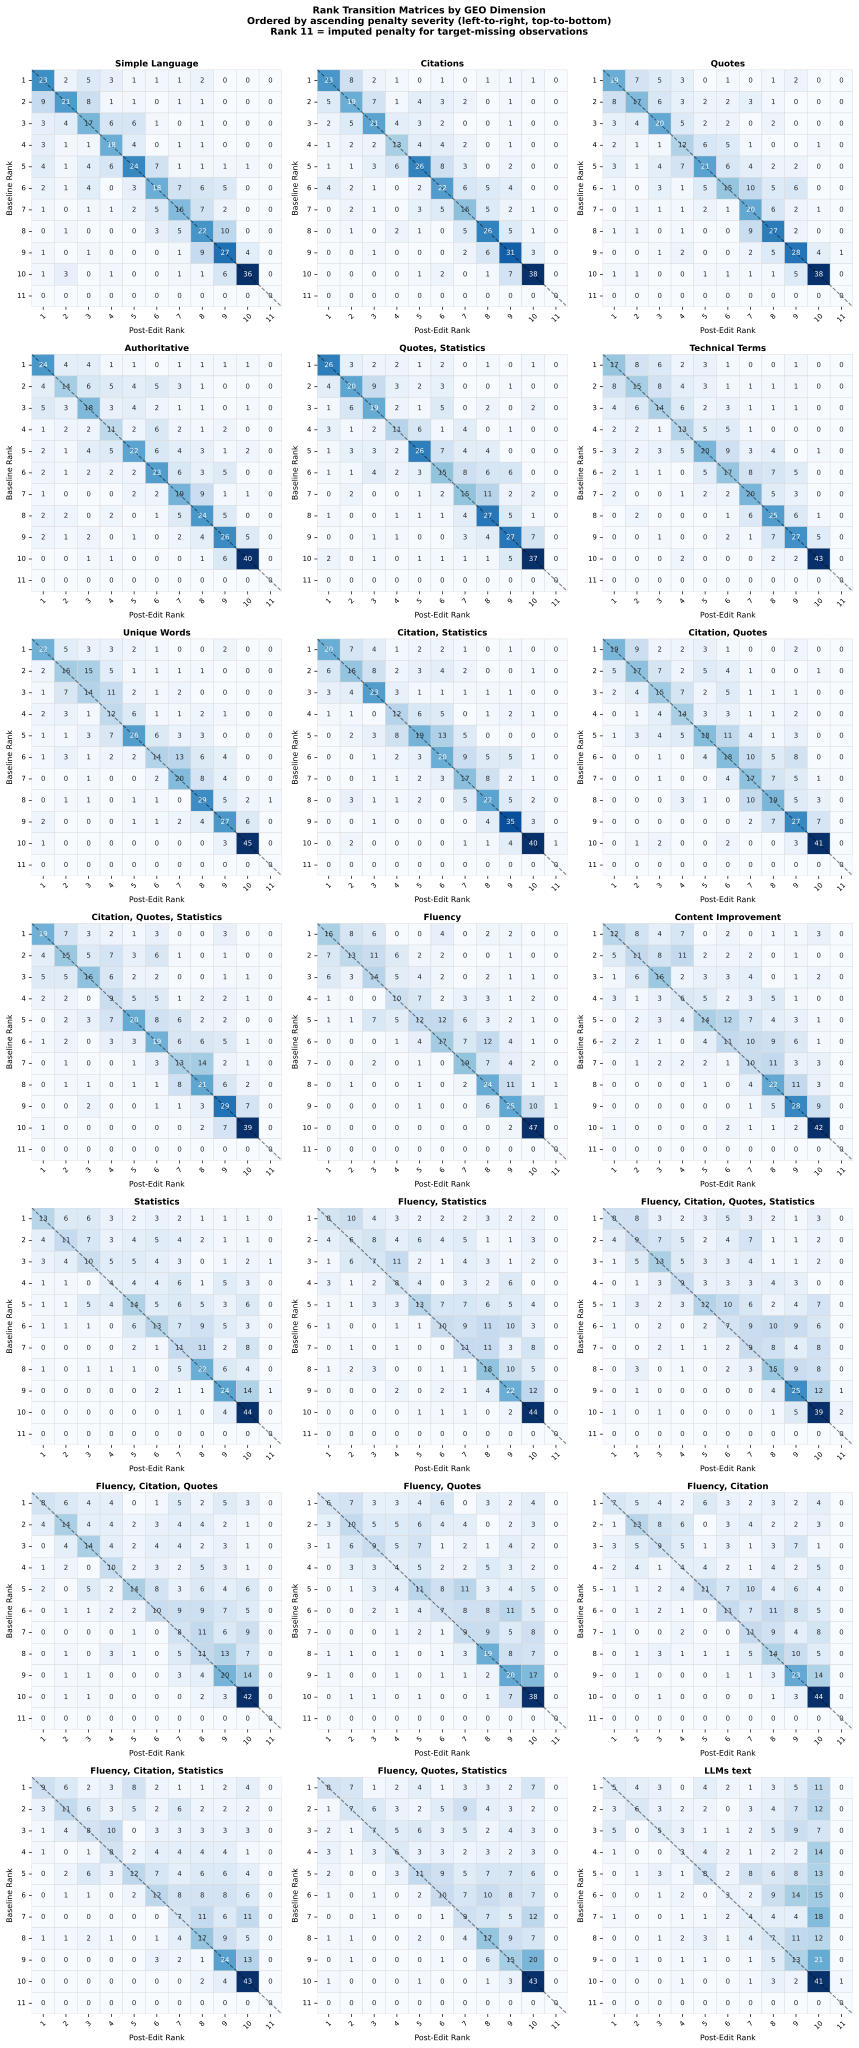

In [14]:
%config InlineBackend.figure_formats = ['svg']

# Derive ordering from paired_df at same sort logic as distribution_table
order_df = strict_paired_df.groupby('dimension').agg(
    Median_Shift=('rank_shift', 'median'),
    Mean_Shift=('rank_shift', 'mean')
).sort_values(by=['Median_Shift', 'Mean_Shift'], ascending=[False, False])
ordered_dimensions = order_df.index.tolist()

ranks = list(range(1, 12))
N_COLS, N_ROWS = 3, 7  

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, 33))
axes_flat = axes.flatten()

for idx, dimension in enumerate(ordered_dimensions):
    ax = axes_flat[idx]
    dim_df = strict_paired_df[strict_paired_df['dimension'] == dimension].copy()
    dim_df['baseline_cat'] = pd.Categorical(dim_df['baseline_rank'], categories=ranks, ordered=True)
    dim_df['edited_cat']   = pd.Categorical(dim_df['edited_rank'],   categories=ranks, ordered=True)

    tm = pd.crosstab(dim_df['baseline_cat'], dim_df['edited_cat'], dropna=False)

    sns.heatmap(
        tm, annot=True, fmt='d', cmap='Blues', cbar=False,
        linewidths=0.4, linecolor='lightgray',
        ax=ax, annot_kws={'size': 8}
    )
    ax.plot([0, 11], [0, 11], 'k--', linewidth=1.2, alpha=0.5)
    ax.set_title(dimension, fontsize=10, fontweight='bold', pad=4)
    ax.set_xlabel('Post-Edit Rank', fontsize=9)
    ax.set_ylabel('Baseline Rank', fontsize=9)
    ax.set_xticklabels([str(r) if r < 11 else '11' for r in ranks], rotation=45, fontsize=8)
    ax.set_yticklabels([str(r) if r < 11 else '11' for r in ranks], rotation=0, fontsize=8)

plt.suptitle(
    'Rank Transition Matrices by GEO Dimension\n'
    'Ordered by ascending penalty severity (left-to-right, top-to-bottom)\n'
    'Rank 11 = imputed penalty for target-missing observations',
    fontsize=11, fontweight='bold', y=1.002
)
plt.tight_layout()
plt.show()

# Reset to PNG for subsequent cells
%config InlineBackend.figure_formats = ['png']

**Findings:**

The matrices show how rank-1-to-10 baseline positions migrate after each GEO edit, with rank 11 reserved for target-missing cases. A strong diagonal indicates rank stability; mass spreading off-diagonal indicates the edit is moving the target document.

- Strong General Stability. Across most dimensions, there is clear diagonal dominance. Baseline ranks are largely preserved post-edit, with the vast majority of rank shifts being minor (moving only 1–2 positions).
- The penalty-severity ordering is broadly empirically supported. Diagonal mass weakens monotonically across the grid: the top-left edits (Simple Language, Citations, Quotes) retain ~25–35 documents per rank on the diagonal, while bottom-right edits (Fluency × Citation × Quotes × Statistics, LLMs text) drop to ~9–17. LLMs text is the clear worst case: rank 1 retains only 9, and probability mass shifts heavily toward ranks 8–10 across nearly every row.
- Most edits perturb but rarely eject. Ghost Target (Column 11) is essentially zero across all dimensions, including the most aggressive multi-dimension edits. The retrieval effect of GEO edits in this setup is reordering within the top-10, not removal.
- Effects are asymmetric and concentrated in the middle ranks. Ranks 4–7 show the largest dispersion under heavy edits, while rank 1 and rank 10 are comparatively sticky. This is the band where GEO edits do most of their work and where wins/losses are most likely to be observed.
- Single-dimension edits are largely conservative; combinations compound. Moving from Fluency alone (diag ≈ 12–24) to Fluency + Citation + Quotes + Statistics (diag ≈ 10–17) shows the expected stacking of perturbation, but the gain from each added dimension is sub-additive

# Hypothesis Testing

In General, the inferential tables below are ordered by descending effect magnitude (largest penalty first), reversing the descriptive ordering above to foreground the strongest evidence.

## Wilcoxon

### Assumptions

**Assumption 1 (Ordinal DV):** The dependent variable must be at least ordinal. Rank shift Δ = r_baseline − r_edited is ordinal, bounded [−10, +10]. Met by the measurement scale; no empirical check required.

**Assumption 2 (Paired observations):** Each observation must consist of two related measurements from the same unit. Baseline and edited ranks are recorded for the same target document under the same base query. Met by the within-subjects design; no empirical check required.

**Assumption 3 (Independent pairs):** Pairs must be independent of one another. Each pair corresponds to a distinct base query; dependence across base queries is eliminated by cluster-wise exclusion of base queries with unstable competitor pools. Met by design; no empirical check required.

**Assumption 4 (Symmetry of differences):** The distribution of Δ must be approximately symmetric around the median for the Wilcoxon test statistic to be interpretable as a median shift. Unlike Assumptions 1–3, this cannot be guaranteed by design and must be assessed empirically. This assumption is tested below.

In [15]:
# Use same ordering as distribution_table
order_df = strict_paired_df.groupby('dimension').agg(
    Median_Shift=('rank_shift', 'median'),
    Mean_Shift=('rank_shift', 'mean')
).sort_values(by=['Median_Shift', 'Mean_Shift'], ascending=[False, False])
ordered_dimensions = order_df.index.tolist()

symmetry_rows = []
for dimension in ordered_dimensions:
    group = strict_paired_df[strict_paired_df['dimension'] == dimension]['rank_shift']
    n = len(group)
    sk = skew(group)
    se = np.sqrt(6 / n)
    z  = sk / se
    symmetry_rows.append({
        'Dimension':              dimension,
        'N':                      n,
        'Skewness':               round(sk, 3),
        'SE (skewness)':          round(se, 4),
        'Standardised z':         round(z, 3),
        'Asymmetric (|z|>1.96)':  abs(z) > 1.96
    })

symmetry_df = pd.DataFrame(symmetry_rows)
display(symmetry_df)

,Dimension,N,Skewness,SE (skewness),Standardised z,Asymmetric (|z|>1.96)
0,Simple Language,411,0.859,0.1208,7.107,True
1,Citations,411,-0.491,0.1208,-4.064,True
2,Quotes,411,0.169,0.1208,1.401,False
3,Authoritative,411,0.249,0.1208,2.063,True
4,"Quotes, Statistics",411,0.239,0.1208,1.975,True
5,Technical Terms,411,0.098,0.1208,0.813,False
6,Unique Words,411,0.520,0.1208,4.302,True
7,"Citation, Statistics",411,-0.054,0.1208,-0.449,False
8,"Citation, Quotes",411,-0.288,0.1208,-2.385,True
9,"Citation, Quotes, Statistics",411,-0.361,0.1208,-2.989,True


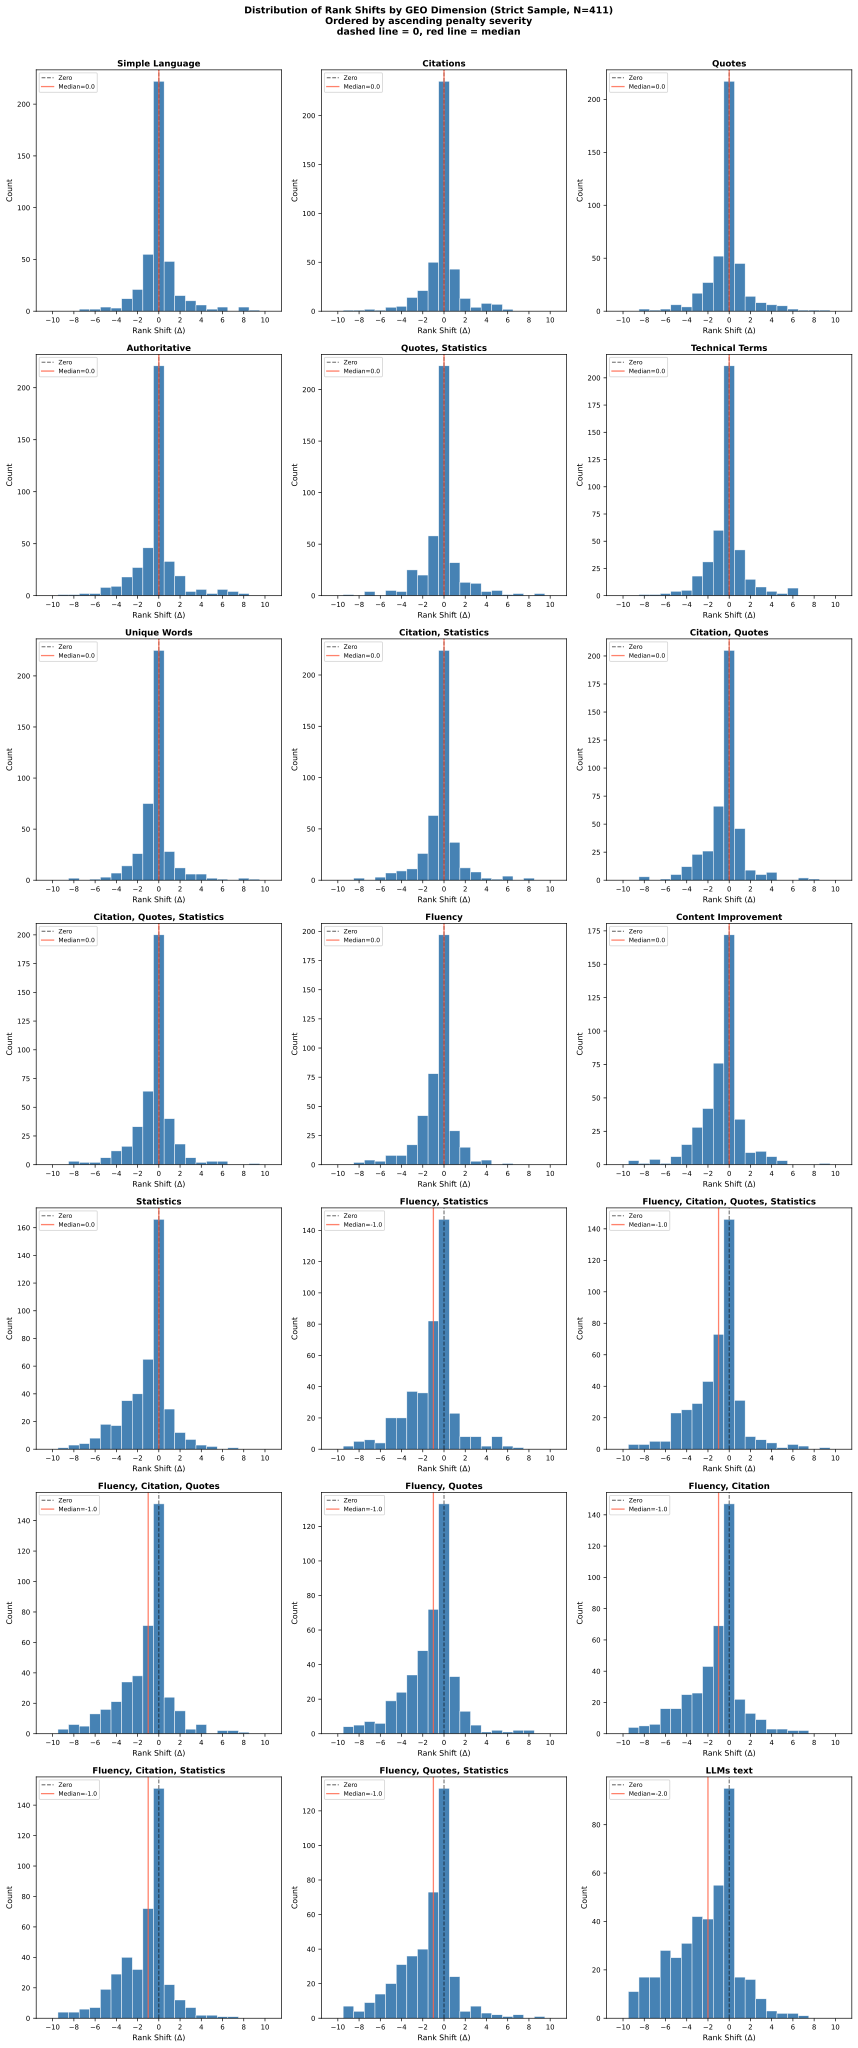

In [16]:
%config InlineBackend.figure_formats = ['svg']

N_COLS, N_ROWS = 3, 7
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, 33))
axes_flat = axes.flatten()

shift_range = range(-10, 11)

for idx, dimension in enumerate(ordered_dimensions):
    ax = axes_flat[idx]
    shifts = strict_paired_df[strict_paired_df['dimension'] == dimension]['rank_shift']
    median_val = shifts.median()

    ax.hist(shifts, bins=range(-10, 12), align='left', color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(0,          color='black',  linestyle='--', linewidth=1.2, alpha=0.6, label='Zero')
    ax.axvline(median_val, color='tomato', linestyle='-',  linewidth=1.5, alpha=0.8, label=f'Median={median_val:.1f}')

    ax.set_title(dimension, fontsize=10, fontweight='bold', pad=4)
    ax.set_xlabel('Rank Shift (Δ)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_xticks(range(-10, 11, 2))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle(
    'Distribution of Rank Shifts by GEO Dimension (Strict Sample, N=411)\n'
    'Ordered by ascending penalty severity\n' 
    'dashed line = 0, red line = median',
    fontsize=11, fontweight='bold', y=1.002
)
plt.tight_layout()
plt.show()

%config InlineBackend.figure_formats = ['png']

**Findings:** 

17 of 21 conditions formally violate the symmetry assumption (|z| > 1.96). Four do not: 
- Quotes (z = 1.40)
- Technical Terms (z = 0.81)
- Citation, Statistics (z = -0.45)
- Fluency, Citation, Quotes, Statistics (z = -1.87). 

Skewness direction follows a clear substantive pattern. Weak-penalty conditions (Simple Language z = 7.11, Unique Words z = 4.30) show positive skew: a dense mass at Δ = 0 with a small right tail of occasional improvements. Stronger-penalty conditions show negative skew: a mass at Δ = 0 or -1 with a left tail of severe degradations, most pronounced for Fluency (z = -9.31) and Statistics (z = -5.73).

Given that 17 of 21 conditions violate symmetry, the Sign Test is adopted uniformly across all 21 rather than selectively. Selective application would impose different inferential standards within the same hypothesis test, which is methodologically inconsistent.

### Testing

In [17]:
def run_wilcoxon_tests(df):
    results = []
    
    # Group by dimension
    for dimension, group in df.groupby('dimension'):
        baseline = group['baseline_rank']
        edited = group['edited_rank']
        
        # Calculate N (Total Pairs)
        n_pairs = len(group)
        
        # Calculate ties just for reporting (optional, but good to know)
        ties = len(group[baseline == edited])
        
        # Pratt keeps zeros in the ranking, so our N remains the full 411.
        valid_n = n_pairs 
        
        # Edge case safety
        if valid_n == ties:
            results.append({'Dimension': dimension, 'Strict N': n_pairs, 'Median Shift': 0.0, 'W-Stat': np.nan, 'p-value': np.nan, 'Effect Size (r)': np.nan, 'Sig.': 'No Shift'})
            continue
            
        try:
            # 1. Run the Wilcoxon Signed-Rank Test WITH PRATT MODIFICATION
            stat, p_val = wilcoxon(baseline, edited, zero_method='pratt', alternative='two-sided')
            
            # 2. Floor p-value at machine epsilon (for reporting only; not used in effect size)
            p_val = max(p_val, 1e-15)
            
            # 3. Compute Z directly from the signed-rank statistic (Pratt)
            #    Avoids float-limit saturation that occurs when inverting extreme p-values via norm.ppf.
            diff = edited.values - baseline.values
            abs_diff = np.abs(diff)
            ranks = rankdata(abs_diff)                  # Pratt: zero-differences are ranked
            w_plus = ranks[diff > 0].sum()
            n_z = int((diff == 0).sum())
            
            mu = (valid_n * (valid_n + 1) - n_z * (n_z + 1)) / 4
            sigma = np.sqrt(
                (valid_n * (valid_n + 1) * (2 * valid_n + 1)
                 - n_z * (n_z + 1) * (2 * n_z + 1)) / 24
            )
            z_stat = (mu - w_plus) / sigma
            
            # 4. Effect size r = |Z| / sqrt(N); standard r
            effect = np.abs(z_stat) / np.sqrt(valid_n)
            
            results.append({
                'Dimension': dimension,
                'Strict N': n_pairs,
                'Median Shift': group['rank_shift'].median(), 
                'W-Stat': stat,
                'p-value': p_val,
                'Effect Size (r)': effect
            })
            
        except ValueError:
            results.append({'Dimension': dimension, 'Strict N': n_pairs, 'Median Shift': np.nan, 'W-Stat': np.nan, 'p-value': np.nan, 'Effect Size (r)': np.nan, 'Sig.': 'Error'})

    # Create the initial dataframe
    res_df = pd.DataFrame(results)
    
    # HOLM-BONFERRONI CORRECTION
    # 1. Apply Holm correction (fillna handles any NaN errors)
    reject, pvals_corrected, _, _ = multipletests(res_df['p-value'].fillna(1.0), alpha=0.05, method='holm')
    
    # 2. Insert the Adjusted p-value right next to the raw p-value
    res_df.insert(5, 'Adj. p-value', pvals_corrected)
    
    # 3. Calculate Significance strictly on the Adjusted p-value
    def assign_sig(p):
        if pd.isna(p): return 'Error'
        elif p < 0.001: return '*** (p<0.001)'
        elif p < 0.01: return '** (p<0.01)'
        elif p < 0.05: return '* (p<0.05)'
        else: return 'ns'
        
    res_df['Sig.'] = res_df['Adj. p-value'].apply(assign_sig)
    
    # Sort by the new Adjusted p-value first, then Effect Size
    res_df = res_df.sort_values(by=['Adj. p-value', 'Effect Size (r)'], ascending=[True, False])
    
    # Format floating points
    formatted_res = res_df.round({'Median Shift': 1, 'W-Stat': 1, 'p-value': 4, 'Adj. p-value': 4, 'Effect Size (r)': 3})
    return formatted_res
    
# Execute the test
wilcoxon_table = run_wilcoxon_tests(strict_paired_df)
display(wilcoxon_table)

,Dimension,Strict N,Median Shift,W-Stat,p-value,Adj. p-value,Effect Size (r),Sig.
14,LLMs text,411,-2.0,9961.5,0.0000,0.0000,0.620,*** (p<0.001)
12,"Fluency, Quotes, Statistics",411,-1.0,10755.0,0.0000,0.0000,0.565,*** (p<0.001)
10,"Fluency, Citation, Statistics",411,-1.0,12020.5,0.0000,0.0000,0.516,*** (p<0.001)
11,"Fluency, Quotes",411,-1.0,14317.0,0.0000,0.0000,0.491,*** (p<0.001)
8,"Fluency, Citation, Quotes",411,-1.0,13900.0,0.0000,0.0000,0.477,*** (p<0.001)
7,"Fluency, Citation",411,-1.0,14218.0,0.0000,0.0000,0.475,*** (p<0.001)
13,"Fluency, Statistics",411,-1.0,14263.0,0.0000,0.0000,0.474,*** (p<0.001)
9,"Fluency, Citation, Quotes, Statistics",411,-1.0,14449.0,0.0000,0.0000,0.472,*** (p<0.001)
18,Statistics,411,0.0,14231.5,0.0000,0.0000,0.448,*** (p<0.001)
6,Fluency,411,0.0,15342.0,0.0000,0.0000,0.374,*** (p<0.001)


In [18]:
# calculate CI for effect sizes

# Seed for reproducability
np.random.seed(42)

# 1. The Core Bootstrapping Function — Z computed directly from W (Pratt)
def bootstrap_effect_size(group, n_iterations=10000):
    baseline = group['baseline_rank'].reset_index(drop=True).values
    edited = group['edited_rank'].reset_index(drop=True).values
    n = len(baseline)
    boot_effects = []
    
    for _ in range(n_iterations):
        indices = np.random.choice(n, size=n, replace=True)
        boot_base = baseline[indices]
        boot_edit = edited[indices]
        
        diff = boot_edit - boot_base
        abs_diff = np.abs(diff)
        n_z = int((diff == 0).sum())
        
        # Skip degenerate resamples where every pair is tied (sigma would be 0)
        if n_z == n:
            continue
        
        ranks = rankdata(abs_diff)            # Pratt: zeros are ranked
        w_plus = ranks[diff > 0].sum()
        
        mu = (n * (n + 1) - n_z * (n_z + 1)) / 4
        sigma = np.sqrt(
            (n * (n + 1) * (2 * n + 1)
             - n_z * (n_z + 1) * (2 * n_z + 1)) / 24
        )
        
        z_stat = (mu - w_plus) / sigma
        effect = np.abs(z_stat) / np.sqrt(n)          
        boot_effects.append(effect)
            
    lower_ci = np.percentile(boot_effects, 2.5)
    upper_ci = np.percentile(boot_effects, 97.5)
    return lower_ci, upper_ci

ci_results = []

# Group by dimension and iterate
for dimension, group in strict_paired_df.groupby('dimension'):
    lower, upper = bootstrap_effect_size(group, n_iterations=10000)
    ci_string = f"[{lower:.3f}, {upper:.3f}]"
    
    ci_results.append({
        'Dimension': dimension,
        'Effect Size 95% CI': ci_string,
        'Lower CI': lower,
        'Upper CI': upper
    })

# Format and Output
ci_df = pd.DataFrame(ci_results)

# Sort by absolute magnitude so your biggest penalties stay at the top
ci_df = ci_df.sort_values(by='Lower CI', ascending=False).drop(columns=['Lower CI', 'Upper CI'])

print("\nBootstrapping Complete. Here are the 95% Confidence Intervals:")
display(ci_df)


Bootstrapping Complete. Here are the 95% Confidence Intervals:


,Dimension,Effect Size 95% CI
14,LLMs text,"[0.558, 0.677]"
12,"Fluency, Quotes, Statistics","[0.496, 0.629]"
10,"Fluency, Citation, Statistics","[0.445, 0.585]"
11,"Fluency, Quotes","[0.414, 0.564]"
8,"Fluency, Citation, Quotes","[0.399, 0.549]"
7,"Fluency, Citation","[0.398, 0.549]"
13,"Fluency, Statistics","[0.395, 0.549]"
9,"Fluency, Citation, Quotes, Statistics","[0.392, 0.545]"
18,Statistics,"[0.369, 0.523]"
6,Fluency,"[0.288, 0.455]"


In [19]:
# merge CI into full table

# Merge the 95% CI column directly into your main Wilcoxon table
final_wilcoxon_table = pd.merge(
    wilcoxon_table, 
    ci_df[['Dimension', 'Effect Size 95% CI']], # We only pull the name and the CI column
    on='Dimension', 
    how='left'
)

# Display
display(final_wilcoxon_table)

,Dimension,Strict N,Median Shift,W-Stat,p-value,Adj. p-value,Effect Size (r),Sig.,Effect Size 95% CI
0,LLMs text,411,-2.0,9961.5,0.0000,0.0000,0.620,*** (p<0.001),"[0.558, 0.677]"
1,"Fluency, Quotes, Statistics",411,-1.0,10755.0,0.0000,0.0000,0.565,*** (p<0.001),"[0.496, 0.629]"
2,"Fluency, Citation, Statistics",411,-1.0,12020.5,0.0000,0.0000,0.516,*** (p<0.001),"[0.445, 0.585]"
3,"Fluency, Quotes",411,-1.0,14317.0,0.0000,0.0000,0.491,*** (p<0.001),"[0.414, 0.564]"
4,"Fluency, Citation, Quotes",411,-1.0,13900.0,0.0000,0.0000,0.477,*** (p<0.001),"[0.399, 0.549]"
5,"Fluency, Citation",411,-1.0,14218.0,0.0000,0.0000,0.475,*** (p<0.001),"[0.398, 0.549]"
6,"Fluency, Statistics",411,-1.0,14263.0,0.0000,0.0000,0.474,*** (p<0.001),"[0.395, 0.549]"
7,"Fluency, Citation, Quotes, Statistics",411,-1.0,14449.0,0.0000,0.0000,0.472,*** (p<0.001),"[0.392, 0.545]"
8,Statistics,411,0.0,14231.5,0.0000,0.0000,0.448,*** (p<0.001),"[0.369, 0.523]"
9,Fluency,411,0.0,15342.0,0.0000,0.0000,0.374,*** (p<0.001),"[0.288, 0.455]"


**Findings:**

For each of the 21 GEO dimensions, baseline vs. edited retrieval ranks across N = 411 paired observations using the Wilcoxon signed-rank test (Pratt's zero-handling, two-sided) were applied with a Holm–Bonferroni correction across dimensions, and the standardized effect size r = |Z|/√N with bootstrapped 95% CIs (10,000 iterations) is reported as the standard non-directional Rosenthal r; the direction of effect for each condition is given by the median rank shift in the descriptive table.

- 18 of 21 dimensions produce a statistically significant degradation in retrieval position after correction; none of the tested edits significantly improve retrieval.
- The most damaging single edit is the full LLMs text rewrite (r = 0.620, CI [0.56, 0.68]), followed by Fluency + Quotes + Statistics (r = 0.565). 
- The Fluency-anchored multi-edit cluster occupies the upper-middle range (r ≈ 0.47 to 0.52), with single-dimension Statistics (r = 0.448) and Fluency (r = 0.374) close behind. 
- Effects taper through the moderate range (Content Improvement, Citation/Quotes/Statistics combinations, Unique Words) and become small but reliable at the tail (Technical Terms, Authoritative).
- Quotes, Citations, and Simple Language alone do not survive correction; Simple Language is the only dimension with a near-zero effect (r = 0.026, CI [0.002, 0.124]), with the lower bound effectively at zero — indicating no detectable retrieval impact.

Note: 

Because 17 of 21 conditions violate the symmetry assumption, the Wilcoxon signed-rank test cannot be interpreted as testing for a shift in the median of differences. Under symmetry violation, the test instead evaluates stochastic dominance: whether one ranking is systematically larger than the other across paired observations. The effect size r retains its meaning as a standardized magnitude indicator (|Z|/√N), but should be interpreted as the strength of stochastic dominance rather than as a standardized median shift. The median shift in the descriptive table is reported separately for transparency but is not the inferential target. 

As r is non-directional, the lower CI bound is constrained at zero; for conditions with near-zero true effect (Simple Language, Citations, Quotes), the lower bound necessarily approaches zero from above. This reflects the standard Rosenthal r definition rather than a feature of the data.

#### Sensitivity Analysis

The strict sample (N = 411 per condition, 8,631 total) excludes all 89 base queries where at least one of the 22 retrieval runs returned fewer than 10 documents. This filter enforces a stable competitive pool across conditions but removes 17.8% of observations. The sensitivity analysis re-runs the identical Wilcoxon signed-rank test on the unfiltered sample (N = 500 per condition, 10,500 total) and compares effect sizes, adjusted p-values, and significance levels side by side. The goal is to detect whether the cluster-wise exclusion systematically selected a biased subset. A missing competitor document reflects a relevance judgement by the retrieval engine (below-threshold documents are legitimately absent), so the unfiltered rank shift remains a valid ordinal measurement, albeit with additional noise from variable pool sizes.

In [20]:
# Run identical Wilcoxon test on unfiltered paired_df (N=500 per condition)
unfiltered_wilcoxon = run_wilcoxon_tests(paired_df)

# Prepare strict columns
strict_cols = wilcoxon_table[['Dimension', 'Strict N', 'Median Shift', 'Effect Size (r)', 'Adj. p-value', 'Sig.']].copy()
strict_cols.columns = ['Dimension', 'N (Strict)', 'Median Shift (Strict)', 'Effect Size (Strict)', 'Adj. p (Strict)', 'Sig. (Strict)']

# Prepare unfiltered columns
unfiltered_cols = unfiltered_wilcoxon[['Dimension', 'Strict N', 'Median Shift', 'Effect Size (r)', 'Adj. p-value', 'Sig.']].copy()
unfiltered_cols.columns = ['Dimension', 'N (Unfiltered)', 'Median Shift (Unfiltered)', 'Effect Size (Unfiltered)', 'Adj. p (Unfiltered)', 'Sig. (Unfiltered)']

# Merge and compute delta
sensitivity_df = pd.merge(strict_cols, unfiltered_cols, on='Dimension', how='outer')
sensitivity_df['Δ Effect Size'] = (sensitivity_df['Effect Size (Unfiltered)'] - sensitivity_df['Effect Size (Strict)']).round(3)
sensitivity_df['Sig. Changed'] = sensitivity_df['Sig. (Strict)'] != sensitivity_df['Sig. (Unfiltered)']

# Sort by strict effect (strongest penalties first; r is non-directional)
sensitivity_df = sensitivity_df.sort_values('Effect Size (Strict)', ascending=False).reset_index(drop=True)

display(sensitivity_df.round({
    'Effect Size (Strict)': 3, 'Effect Size (Unfiltered)': 3,
    'Adj. p (Strict)': 4, 'Adj. p (Unfiltered)': 4
}))

,Dimension,N (Strict),Median Shift (Strict),Effect Size (Strict),Adj. p (Strict),Sig. (Strict),N (Unfiltered),Median Shift (Unfiltered),Effect Size (Unfiltered),Adj. p (Unfiltered),Sig. (Unfiltered),Δ Effect Size,Sig. Changed
0,LLMs text,411,-2.0,0.620,0.0000,*** (p<0.001),500,-2.0,0.625,0.0000,*** (p<0.001),0.005,False
1,"Fluency, Quotes, Statistics",411,-1.0,0.565,0.0000,*** (p<0.001),500,-1.0,0.561,0.0000,*** (p<0.001),-0.004,False
2,"Fluency, Citation, Statistics",411,-1.0,0.516,0.0000,*** (p<0.001),500,-1.0,0.499,0.0000,*** (p<0.001),-0.017,False
3,"Fluency, Quotes",411,-1.0,0.491,0.0000,*** (p<0.001),500,-1.0,0.491,0.0000,*** (p<0.001),0.000,False
4,"Fluency, Citation, Quotes",411,-1.0,0.477,0.0000,*** (p<0.001),500,-0.5,0.482,0.0000,*** (p<0.001),0.005,False
5,"Fluency, Citation",411,-1.0,0.475,0.0000,*** (p<0.001),500,-1.0,0.474,0.0000,*** (p<0.001),-0.001,False
6,"Fluency, Statistics",411,-1.0,0.474,0.0000,*** (p<0.001),500,-1.0,0.472,0.0000,*** (p<0.001),-0.002,False
7,"Fluency, Citation, Quotes, Statistics",411,-1.0,0.472,0.0000,*** (p<0.001),500,-1.0,0.475,0.0000,*** (p<0.001),0.003,False
8,Statistics,411,0.0,0.448,0.0000,*** (p<0.001),500,0.0,0.463,0.0000,*** (p<0.001),0.015,False
9,Fluency,411,0.0,0.374,0.0000,*** (p<0.001),500,0.0,0.366,0.0000,*** (p<0.001),-0.008,False


**Findings:** 

The rank ordering of conditions by penalty severity is identical in both samples. Δ Effect Size magnitudes are small throughout (range: -0.022 to +0.023), with no systematic directional pattern. For both high-penalty conditions and low-penalty conditions, strict estimates are not stronger (Δ > 0) or weaker (Δ < 0) than unfiltered estimates and remain negligible in magnitude. 

Two conditions show a significance tier change:

- **Authoritative** moves from `*` (p = 0.026) in the strict sample to `**` (p = 0.002) in the unfiltered sample; both significant, differing only in tier. 

- **Quotes** moves from `ns` (p = 0.118) in the strict sample to borderline `*` (p = 0.048) in the unfiltered sample. The Quotes result reflects a genuinely marginal effect near the decision boundary rather than a filter-induced distortion; the conservative strict estimate is the appropriate basis for inference. 

Overall, the cluster-wise exclusion does not introduce directional bias into the primary estimates, and the strict sample results are robust.

## Sign Test

### Assumptions

**Assumption 1 (Ordinal DV):** The dependent variable must be at least ordinal. Rank shift Δ = r_baseline - r_edited is ordinal, bounded [-10, +10]. Met by the measurement scale; no empirical check required.

**Assumption 2 (Paired observations):** Each observation must consist of two related measurements from the same unit. Baseline and edited ranks are recorded for the same target document under the same base query. Met by the within-subjects design; no empirical check required.

**Assumption 3 (Independent pairs):** Pairs must be independent of one another. Each pair corresponds to a distinct base query; dependence across base queries is eliminated by cluster-wise exclusion of base queries with unstable competitor pools. Met by design; no empirical check required.

**Assumption 4 (Continuous differences):** The Sign Test formally requires a continuous distribution of differences to ensure a unique median (P(Δ = 0) = 0). This is technically violated because rank shifts are integer-valued, producing ties at Δ = 0. In practice, zero-tied pairs are excluded from the test statistic, reducing effective N per condition; effective N is reported alongside each result. The violation affects precision but not validity.

### Testing

In [21]:
def run_sign_tests(df):
    results = []

    for dimension, group in df.groupby('dimension'):
        shifts  = group['rank_shift']
        n_total = len(shifts)
        n_pos   = int((shifts > 0).sum())
        n_neg   = int((shifts < 0).sum())
        n_zero  = int((shifts == 0).sum())
        n_eff   = n_pos + n_neg

        if n_eff == 0:
            results.append({
                'Dimension': dimension, 'N (Total)': n_total,
                'N (Effective)': 0, 'N (Zeros)': n_zero,
                'N (+)': 0, 'N (-)': 0,
                'p̂': np.nan, "Cohen's g": np.nan, 'p-value': np.nan
            })
            continue

        p_val  = binomtest(n_pos, n_eff, 0.5, alternative='two-sided').pvalue
        p_hat  = n_pos / n_eff
        # Cohen's g = |p̂ − 0.5| (non-directional, magnitude only)
        effect = round(abs(p_hat - 0.5), 3)

        results.append({
            'Dimension':     dimension,
            'N (Total)':     n_total,
            'N (Effective)': n_eff,
            'N (Zeros)':     n_zero,
            'N (+)':         n_pos,
            'N (-)':         n_neg,
            'p̂':            round(p_hat, 3),
            "Cohen's g":     effect,
            'p-value':       p_val
        })

    res_df = pd.DataFrame(results)

    # Holm-Bonferroni correction
    reject, p_adj, _, _ = multipletests(res_df['p-value'].fillna(1.0), alpha=0.05, method='holm')
    res_df.insert(res_df.columns.get_loc('p-value') + 1, 'Adj. p-value', p_adj)

    def sig(p):
        if pd.isna(p):  return 'Error'
        if p < 0.001:   return '*** (p<0.001)'
        if p < 0.01:    return '** (p<0.01)'
        if p < 0.05:    return '* (p<0.05)'
        return 'ns'

    res_df['Sig.'] = res_df['Adj. p-value'].apply(sig)
    res_df = res_df.sort_values(['Adj. p-value', "Cohen's g"], ascending=[True, False]).reset_index(drop=True)
    return res_df

sign_test_table = run_sign_tests(strict_paired_df)
display(sign_test_table.round({'p-value': 4, 'Adj. p-value': 4}))

,Dimension,N (Total),N (Effective),N (Zeros),N (+),N (-),p̂,Cohen's g,p-value,Adj. p-value,Sig.
0,LLMs text,411,316,95,49,267,0.155,0.345,0.0000,0.0000,*** (p<0.001)
1,"Fluency, Quotes, Statistics",411,278,133,44,234,0.158,0.342,0.0000,0.0000,*** (p<0.001)
2,"Fluency, Citation, Statistics",411,260,151,47,213,0.181,0.319,0.0000,0.0000,*** (p<0.001)
3,"Fluency, Statistics",411,264,147,52,212,0.197,0.303,0.0000,0.0000,*** (p<0.001)
4,"Fluency, Citation",411,264,147,54,210,0.205,0.295,0.0000,0.0000,*** (p<0.001)
5,"Fluency, Quotes",411,278,133,59,219,0.212,0.288,0.0000,0.0000,*** (p<0.001)
6,"Fluency, Citation, Quotes",411,260,151,53,207,0.204,0.296,0.0000,0.0000,*** (p<0.001)
7,"Fluency, Citation, Quotes, Statistics",411,265,146,56,209,0.211,0.289,0.0000,0.0000,*** (p<0.001)
8,Statistics,411,245,166,54,191,0.220,0.280,0.0000,0.0000,*** (p<0.001)
9,Fluency,411,214,197,52,162,0.243,0.257,0.0000,0.0000,*** (p<0.001)


In [22]:
# Side-by-side comparison of Sign Test vs Wilcoxon
comp = pd.merge(
    wilcoxon_table[['Dimension', 'Median Shift', 'Effect Size (r)', 'Adj. p-value', 'Sig.']].rename(
        columns={'Effect Size (r)': 'WSR r', 'Adj. p-value': 'WSR Adj. p', 'Sig.': 'WSR Sig.'}
    ),
    sign_test_table[['Dimension', "Cohen's g", 'Adj. p-value', 'Sig.']].rename(
        columns={"Cohen's g": 'ST g', 'Adj. p-value': 'ST Adj. p', 'Sig.': 'ST Sig.'}
    ),
    on='Dimension', how='inner'
)
comp['Concordant'] = comp['WSR Sig.'] == comp['ST Sig.']

# Sort by Wilcoxon r (strongest penalties first; r is non-directional)
comp = comp.sort_values('WSR r', ascending=False).reset_index(drop=True)

print(f"Concordant conditions: {comp['Concordant'].sum()} / {len(comp)}")
display(comp.round({'WSR r': 3, 'ST g': 3, 'WSR Adj. p': 4, 'ST Adj. p': 4}))

Concordant conditions: 20 / 21


,Dimension,Median Shift,WSR r,WSR Adj. p,WSR Sig.,ST g,ST Adj. p,ST Sig.,Concordant
0,LLMs text,-2.0,0.620,0.0000,*** (p<0.001),0.345,0.0000,*** (p<0.001),True
1,"Fluency, Quotes, Statistics",-1.0,0.565,0.0000,*** (p<0.001),0.342,0.0000,*** (p<0.001),True
2,"Fluency, Citation, Statistics",-1.0,0.516,0.0000,*** (p<0.001),0.319,0.0000,*** (p<0.001),True
3,"Fluency, Quotes",-1.0,0.491,0.0000,*** (p<0.001),0.288,0.0000,*** (p<0.001),True
4,"Fluency, Citation, Quotes",-1.0,0.477,0.0000,*** (p<0.001),0.296,0.0000,*** (p<0.001),True
5,"Fluency, Citation",-1.0,0.475,0.0000,*** (p<0.001),0.295,0.0000,*** (p<0.001),True
6,"Fluency, Statistics",-1.0,0.474,0.0000,*** (p<0.001),0.303,0.0000,*** (p<0.001),True
7,"Fluency, Citation, Quotes, Statistics",-1.0,0.472,0.0000,*** (p<0.001),0.289,0.0000,*** (p<0.001),True
8,Statistics,0.0,0.448,0.0000,*** (p<0.001),0.280,0.0000,*** (p<0.001),True
9,Fluency,0.0,0.374,0.0000,*** (p<0.001),0.257,0.0000,*** (p<0.001),True


**Findings:**

20 of 21 conditions are concordant in significance tier between the Sign Test and the Wilcoxon. The sole discordant condition is **Technical Terms**, which shifts from `**` (Wilcoxon, p = 0.010) to `*` (Sign Test, p = 0.011), a one-tier downgrade that does not cross the significance boundary; the effect remains significant under both tests.

All 11 conditions significant at `***` under the Wilcoxon retain `***` under the Sign Test. The three Wilcoxon-`ns` conditions (Quotes, Citations, Simple Language) also remain `ns`, confirming that the null result for these conditions is robust to distributional form, not an artefact of the symmetry violation.

Cohen's g (magnitude) is non-zero for all 20 significant conditions, confirming that the imbalance between rank degradations and rank improvements is reliable. 
Direction is given by the N(+) and N(−) columns: across all 20 significant conditions, N(−) > N(+), confirming GEO edits increase the probability of rank degradation over rank improvement. The magnitude of g is smaller than the corresponding Wilcoxon r throughout, which is expected — the Sign Test discards within-pair magnitude information, retaining only direction.

Two structural observations from the Sign Test output are noteworthy:

- **High zero rates in weak-penalty conditions**: Simple Language (222/411 = 54% zero shifts), Citations (235/411 = 57%), and Quotes (217/411 = 53%) show that for the majority of query pairs, these GEO edits produce no rank change at all. This is substantively consistent with the near-zero mean and median shifts in the descriptive tables — these conditions are not merely weak in effect size, but largely inert for most documents.

- **LLMs text has the most extreme sign imbalance**: only 49 of 316 effective pairs (p̂ = 0.155) show a rank improvement, meaning 84.5% of non-zero pairs are degradations. This is the strongest directional signal in the experiment and confirms LLMs text as the most harmful GEO dimension for retrieval visibility.

Therefore, despite the symmetry violation, we retain Wilcoxon as primary because (a) it has higher power than the Sign Test under stochastic dominance, (b) the violation is in skewness rather than tail behavior, and (c) the Sign Test concordance (20/21 conditions) confirms the inferential conclusions are robust to the violation.